# RCP211 - Inverse Reinforcment Learning - Fayz El Razaz

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 22       |
|    ep_rew_mean     | 22       |
| time/              |          |
|    fps             | 739      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 24.6        |
|    ep_rew_mean          | 24.6        |
| time/                   |             |
|    fps                  | 490         |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008349771 |
|    clip_fraction        | 0.0965      |
|    clip_range           | 0.2         |
|    entropy_loss   

/home/intifada/Documents/rcp211/.venv/lib/python3.12/site-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(
100%|██████████| 20/20 [00:00<00:00, 415.90it/s]



=== Évaluation finale sur la vraie reward CartPole ===
Random       : 30.60 ± 15.10
Expert PPO   : 383.20 ± 108.31
IRL niveau 1 : 291.35 ± 91.58


100%|██████████| 100/100 [00:00<00:00, 48703.02it/s]


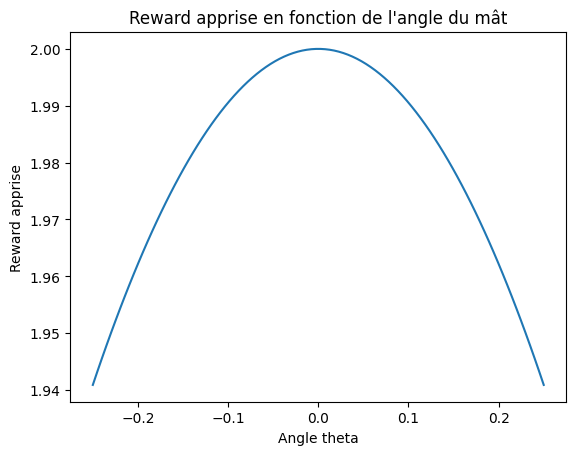

In [4]:
# pip install gymnasium stable-baselines3 scipy numpy pandas matplotlib

import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from tqdm import tqdm

ENV_ID = "CartPole-v1"
SEED = 42
np.random.seed(SEED)


# ============================================================
# 1. Entraîner un expert PPO avec la vraie reward CartPole
# ============================================================

expert_env = gym.make(ENV_ID)

expert = PPO(
    "MlpPolicy",
    expert_env,
    seed=SEED,
    verbose=1,
)

expert.learn(total_timesteps=10000)

expert_score, expert_std = evaluate_policy(
    expert,
    gym.make(ENV_ID),
    n_eval_episodes=20,
)

print(f"Expert PPO : {expert_score:.2f} ± {expert_std:.2f}")


# ============================================================
# 2. Collecter des trajectoires expert et random
# ============================================================

def collect_trajectories(policy_type, n_episodes=100):
    env = gym.make(ENV_ID)

    trajectories = []

    for ep in range(n_episodes):
        obs, info = env.reset(seed=SEED + ep)

        done = False
        truncated = False

        obs_list = []
        reward_list = []

        while not (done or truncated):
            if policy_type == "expert":
                action, _ = expert.predict(obs, deterministic=True)
                action = int(action)
            elif policy_type == "random":
                action = env.action_space.sample()
            else:
                raise ValueError("policy_type doit être 'expert' ou 'random'")

            next_obs, reward, done, truncated, info = env.step(action)

            obs_list.append(obs)
            reward_list.append(reward)

            obs = next_obs

        trajectories.append({
            "obs": np.array(obs_list, dtype=np.float32),
            "env_return": np.sum(reward_list),
            "length": len(obs_list),
        })

    env.close()
    return trajectories


expert_trajs = collect_trajectories("expert", n_episodes=50)
random_trajs = collect_trajectories("random", n_episodes=50)

print("Longueur moyenne expert :", np.mean([t["length"] for t in expert_trajs]))
print("Longueur moyenne random :", np.mean([t["length"] for t in random_trajs]))


# ============================================================
# 3. Features physiques de CartPole
# ============================================================

def state_features(obs):
    """
    obs = [x, x_dot, theta, theta_dot]

    On construit des pénalités positives.
    Plus elles sont grandes, plus l'état est mauvais.
    """
    x, x_dot, theta, theta_dot = obs

    return np.array([
        x ** 2,
        x_dot ** 2,
        theta ** 2,
        theta_dot ** 2,
    ], dtype=np.float32)


def trajectory_features(traj):
    """
    Somme des features sur toute la trajectoire.
    """
    return np.mean([state_features(obs) for obs in traj["obs"]], axis=0)


expert_features = np.array([trajectory_features(t) for t in expert_trajs])
random_features = np.array([trajectory_features(t) for t in random_trajs])


# ============================================================
# 4. Apprendre les poids de la reward
# ============================================================

def reward_from_features(phi, w):
    """
    Reward paramétrique :

    R(s) = - w . phi(s)

    avec phi(s) = [x², x_dot², theta², theta_dot²]
    """
    return 2-np.dot(phi, w)


def loss(w):
    """
    On veut que les trajectoires expertes aient une reward cumulée
    supérieure aux trajectoires random.

    Comme R = -w.phi, cela revient à donner une pénalité plus faible
    aux trajectoires expertes.
    """
    expert_scores = -expert_features @ w
    random_scores = -random_features @ w

    # Comparaison moyenne expert vs random
    expert_mean = expert_scores.mean()
    random_mean = random_scores.mean()

    margin = 1.0

    ranking_loss = max(0.0, margin - (expert_mean - random_mean))

    # Régularisation pour éviter des poids énormes
    regularization = 0.01 * np.sum(w ** 2)

    return ranking_loss + regularization


initial_w = np.ones(4)

result = minimize(
    loss,
    x0=initial_w,
    bounds=[(0, None)] * 4,
    method="L-BFGS-B",
)

w_learned = result.x

print("\nPoids appris :")
print(f"x²          : {w_learned[0]:.4f}")
print(f"x_dot²      : {w_learned[1]:.4f}")
print(f"theta²      : {w_learned[2]:.4f}")
print(f"theta_dot²  : {w_learned[3]:.4f}")


# ============================================================
# 5. Comparer reward apprise expert vs random
# ============================================================

def learned_return(traj, w):
    return np.mean([
        reward_from_features(state_features(obs), w)
        for obs in traj["obs"]
    ])


expert_learned_returns = np.array([
    learned_return(t, w_learned) for t in expert_trajs
])

random_learned_returns = np.array([
    learned_return(t, w_learned) for t in random_trajs
])

comparison = pd.DataFrame({
    "policy": ["Expert", "Random"],
    "env_return_mean": [
        np.mean([t["env_return"] for t in expert_trajs]),
        np.mean([t["env_return"] for t in random_trajs]),
    ],
    "learned_return_mean": [
        expert_learned_returns.mean(),
        random_learned_returns.mean(),
    ],
    "trajectory_length_mean": [
        np.mean([t["length"] for t in expert_trajs]),
        np.mean([t["length"] for t in random_trajs]),
    ],
})

print("\nComparaison expert vs random :")
print(comparison)


# ============================================================
# 6. Créer un environnement CartPole avec reward apprise
# ============================================================

class LearnedRewardCartPole(gym.Wrapper):
    def __init__(self, env, w):
        super().__init__(env)
        self.w = w

    def step(self, action):
        obs, original_reward, terminated, truncated, info = self.env.step(action)

        phi = state_features(obs)
        learned_reward = 2+ reward_from_features(phi, self.w)

        info["original_reward"] = original_reward
        info["learned_reward"] = learned_reward

        return obs, learned_reward, terminated, truncated, info


learned_env = LearnedRewardCartPole(
    gym.make(ENV_ID),
    w_learned,
)


# ============================================================
# 7. Entraîner un nouvel agent PPO sur la reward apprise
# ============================================================

irl_agent = PPO(
    "MlpPolicy",
    learned_env,
    seed=SEED,
    verbose=1,
)

irl_agent.learn(total_timesteps=10000)


# ============================================================
# 8. Évaluer l'agent IRL sur la vraie reward CartPole
# ============================================================

eval_env = gym.make(ENV_ID)

irl_score, irl_std = evaluate_policy(
    irl_agent,
    eval_env,
    n_eval_episodes=20,
)

random_scores = []

for ep in tqdm(range(20)):
    env = gym.make(ENV_ID)
    obs, info = env.reset(seed=SEED + ep)

    done = False
    truncated = False
    total_reward = 0

    while not (done or truncated):
        action = env.action_space.sample()
        obs, reward, done, truncated, info = env.step(action)
        total_reward += reward

    random_scores.append(total_reward)
    env.close()

print("\n=== Évaluation finale sur la vraie reward CartPole ===")
print(f"Random       : {np.mean(random_scores):.2f} ± {np.std(random_scores):.2f}")
print(f"Expert PPO   : {expert_score:.2f} ± {expert_std:.2f}")
print(f"IRL niveau 1 : {irl_score:.2f} ± {irl_std:.2f}")


# ============================================================
# 9. Visualiser la reward apprise selon l'angle theta
# ============================================================

angles = np.linspace(-0.25, 0.25, 100)

rewards_angle = []

for theta in tqdm(angles):
    obs = np.array([0.0, 0.0, theta, 0.0])
    phi = state_features(obs)
    rewards_angle.append(reward_from_features(phi, w_learned))

plt.figure()
plt.plot(angles, rewards_angle)
plt.xlabel("Angle theta")
plt.ylabel("Reward apprise")
plt.title("Reward apprise en fonction de l'angle du mât")
plt.show()

## Construction de l'expert et des démonstrations

### Librairie

In [ ]:
import os
import numpy as np
import gymnasium as gym

from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

### Configuration

In [5]:
# =========================
# Configuration
# =========================

ENV_NAME = "CartPole-v1"

ROOT_DIR = os.getcwd ()
MODEL_DIR = os.path.join(ROOT_DIR, "models")
DATA_DIR = os.path.join(ROOT_DIR, "data")

EXPERT_MODEL_PATH = os.path.join(MODEL_DIR, "ppo_cartpole_expert")
DEMO_DATA_PATH = os.path.join(DATA_DIR, "expert_demonstrations.npz")

N_TRAINING_STEPS = 100_000
N_DEMO_EPISODES = 50
MIN_EXPERT_SCORE = 450

SEED = 42

### Préparation des dossiers

In [8]:
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

### Entraintement de notre expert

In [9]:
# =========================
# 1. Entraînement expert PPO
# =========================

env = gym.make(ENV_NAME)

model = PPO(
    policy="MlpPolicy",
    env=env,
    verbose=1,
    seed=SEED,
)

model.learn(total_timesteps=N_TRAINING_STEPS)

model.save(EXPERT_MODEL_PATH)

mean_reward, std_reward = evaluate_policy(
    model,
    env,
    n_eval_episodes=20,
    deterministic=True,
)

print("\n=== Évaluation de l'expert PPO ===")
print(f"Score moyen : {mean_reward:.2f} ± {std_reward:.2f}")


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 22       |
|    ep_rew_mean     | 22       |
| time/              |          |
|    fps             | 610      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 24.6        |
|    ep_rew_mean          | 24.6        |
| time/                   |             |
|    fps                  | 489         |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008349771 |
|    clip_fraction        | 0.0965      |
|    clip_range           | 0.2         |
|    entropy_loss   

/home/intifada/Documents/rcp211/.venv/lib/python3.12/site-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(



=== Évaluation de l'expert PPO ===
Score moyen : 500.00 ± 0.00


### Collecte des démonstrations

In [10]:
# =========================
# 2. Collecte des démonstrations expertes
# =========================

demo_env = gym.make(ENV_NAME)

trajectories = []

episode_id = 0

while len(trajectories) < N_DEMO_EPISODES:
    obs, info = demo_env.reset(seed=SEED + episode_id)

    states = []
    actions = []
    rewards = []
    next_states = []
    dones = []

    done = False
    truncated = False
    episode_reward = 0

    while not (done or truncated):
        action, _ = model.predict(obs, deterministic=True)

        next_obs, reward, done, truncated, info = demo_env.step(action)

        states.append(obs)
        actions.append(action)
        rewards.append(reward)
        next_states.append(next_obs)
        dones.append(done or truncated)

        obs = next_obs
        episode_reward += reward

    if episode_reward >= MIN_EXPERT_SCORE:
        trajectory = {
            "states": np.array(states, dtype=np.float32),
            "actions": np.array(actions, dtype=np.int64),
            "rewards": np.array(rewards, dtype=np.float32),
            "next_states": np.array(next_states, dtype=np.float32),
            "dones": np.array(dones, dtype=bool),
            "episode_reward": episode_reward,
        }

        trajectories.append(trajectory)

        print(
            f"Trajectoire retenue {len(trajectories)}/{N_DEMO_EPISODES} "
            f"- score = {episode_reward}"
        )
    else:
        print(f"Trajectoire rejetée - score = {episode_reward}")

    episode_id += 1

Trajectoire retenue 1/50 - score = 500.0
Trajectoire retenue 2/50 - score = 500.0
Trajectoire retenue 3/50 - score = 500.0
Trajectoire retenue 4/50 - score = 500.0
Trajectoire retenue 5/50 - score = 500.0
Trajectoire retenue 6/50 - score = 500.0
Trajectoire retenue 7/50 - score = 500.0
Trajectoire retenue 8/50 - score = 500.0
Trajectoire retenue 9/50 - score = 500.0
Trajectoire retenue 10/50 - score = 500.0
Trajectoire retenue 11/50 - score = 500.0
Trajectoire retenue 12/50 - score = 500.0
Trajectoire retenue 13/50 - score = 500.0
Trajectoire retenue 14/50 - score = 500.0
Trajectoire retenue 15/50 - score = 500.0
Trajectoire retenue 16/50 - score = 500.0
Trajectoire retenue 17/50 - score = 500.0
Trajectoire retenue 18/50 - score = 500.0
Trajectoire retenue 19/50 - score = 500.0
Trajectoire retenue 20/50 - score = 500.0
Trajectoire retenue 21/50 - score = 500.0
Trajectoire retenue 22/50 - score = 500.0
Trajectoire retenue 23/50 - score = 500.0
Trajectoire retenue 24/50 - score = 500.0
T

### Construction du dataset

In [11]:
# =========================
# 3. Construction d'un dataset aplati
# =========================

all_states = np.concatenate([traj["states"] for traj in trajectories], axis=0)
all_actions = np.concatenate([traj["actions"] for traj in trajectories], axis=0)
all_rewards = np.concatenate([traj["rewards"] for traj in trajectories], axis=0)
all_next_states = np.concatenate([traj["next_states"] for traj in trajectories], axis=0)
all_dones = np.concatenate([traj["dones"] for traj in trajectories], axis=0)

episode_rewards = np.array(
    [traj["episode_reward"] for traj in trajectories],
    dtype=np.float32,
)

### Sauvegarde

In [14]:
# =========================
# 4. Sauvegarde
# =========================

np.savez(
    DEMO_DATA_PATH,
    states=all_states,
    actions=all_actions,
    rewards=all_rewards,
    next_states=all_next_states,
    dones=all_dones,
    episode_rewards=episode_rewards,
)

print("\n=== Dataset de démonstrations sauvegardé ===")
print(f"Chemin : {DEMO_DATA_PATH}")
print(f"Nombre de trajectoires : {len(trajectories)}")
print(f"Nombre total de transitions : {len(all_states)}")
print(f"Dimension des états : {all_states.shape}")
print(f"Dimension des actions : {all_actions.shape}")
print(f"Score moyen des démonstrations : {episode_rewards.mean():.2f}")


=== Dataset de démonstrations sauvegardé ===
Chemin : /home/intifada/Documents/rcp211/04_Projet/data/expert_demonstrations.npz
Nombre de trajectoires : 50
Nombre total de transitions : 25000
Dimension des états : (25000, 4)
Dimension des actions : (25000,)
Score moyen des démonstrations : 500.00


## Construction du modèle de reward

### Environement & Librairies

In [7]:
import os
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

N_RANDOM_EPISODES = 100
N_EPOCHS = 100
BATCH_SIZE = 256
LR = 1e-3
SEED = 42

os.makedirs(MODEL_DIR, exist_ok=True)

### Modèles de rewards

In [8]:
# ============================================================
# 1. Modèles de reward
# ============================================================

class LinearReward(nn.Module):
    """
    Reward linéaire :
    r(s) = w^T s + b
    """

    def __init__(self, state_dim):
        super().__init__()
        self.linear = nn.Linear(state_dim, 1)

    def forward(self, state):
        return self.linear(state)


class QuadraticReward(nn.Module):
    """
    Reward quadratique :
    r(s) = w^T [s, s^2] + b

    On enrichit les features avec les carrés des variables.
    """

    def __init__(self, state_dim):
        super().__init__()
        self.linear = nn.Linear(2 * state_dim, 1)

    def forward(self, state):
        features = torch.cat([state, state ** 2], dim=1)
        return self.linear(features)


class NeuralReward(nn.Module):
    """
    Reward non linéaire par réseau de neurones.
    """

    def __init__(self, state_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, state):
        return self.net(state)

### Classe d'entrainement

In [ ]:
# ============================================================
# 2. Classe d'entraînement commune
# ============================================================

class RewardTrainer:
    def __init__(
        self,
        demo_data_path,
        n_random_episodes=1000,
        batch_size=256,
        lr=1e-3,
        n_epochs=100,
        seed=42,
    ):
        self.demo_data_path = demo_data_path
        self.n_random_episodes = n_random_episodes
        self.batch_size = batch_size
        self.lr = lr
        self.n_epochs = n_epochs
        self.seed = seed

        self.scaler = StandardScaler()

        self.X_tensor = None
        self.y_tensor = None
        self.expert_states = None
        self.random_states = None

    def load_expert_states(self):
        data = np.load(self.demo_data_path)
        self.expert_states = data["states"].astype(np.float32)

        print("États experts :", self.expert_states.shape)

    def generate_random_states(self):
        env = gym.make(ENV_NAME)

        random_states = []

        for episode in range(self.n_random_episodes):
            obs, info = env.reset(seed=self.seed + episode)
            done = False
            truncated = False

            while not (done or truncated):
                action = env.action_space.sample()
                next_obs, reward, done, truncated, info = env.step(action)

                random_states.append(obs)
                obs = next_obs

        self.random_states = np.array(random_states, dtype=np.float32)

        print("États random :", self.random_states.shape)

    def build_dataset(self):
        n = min(len(self.expert_states), len(self.random_states))

        self.expert_states = self.expert_states[:n]
        self.random_states = self.random_states[:n]

        X = np.concatenate([self.expert_states, self.random_states], axis=0)

        y_expert = np.ones((n, 1), dtype=np.float32)
        y_random = np.zeros((n, 1), dtype=np.float32)
        y = np.concatenate([y_expert, y_random], axis=0)

        rng = np.random.default_rng(self.seed)
        indices = rng.permutation(len(X))

        X = X[indices]
        y = y[indices]

        X_scaled = self.scaler.fit_transform(X).astype(np.float32)

        self.X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
        self.y_tensor = torch.tensor(y, dtype=torch.float32)

    def prepare_data(self):
        self.load_expert_states()
        self.generate_random_states()
        self.build_dataset()

    def train_model(self, model, model_name):
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(model.parameters(), lr=self.lr)

        dataset_size = len(self.X_tensor)

        for epoch in range(self.n_epochs):
            permutation = torch.randperm(dataset_size)

            epoch_loss = 0.0

            for i in range(0, dataset_size, self.batch_size):
                batch_idx = permutation[i:i + self.batch_size]

                batch_X = self.X_tensor[batch_idx]
                batch_y = self.y_tensor[batch_idx]

                logits = model(batch_X)
                loss = criterion(logits, batch_y)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()

            if (epoch + 1) % 10 == 0:
                print(
                    f"{model_name} | Epoch {epoch + 1}/{self.n_epochs} "
                    f"- Loss : {epoch_loss:.4f}"
                )

        return model

    def evaluate_model(self, model, model_name):
        with torch.no_grad():
            expert_scaled = self.scaler.transform(self.expert_states).astype(np.float32)
            random_scaled = self.scaler.transform(self.random_states).astype(np.float32)

            expert_tensor = torch.tensor(expert_scaled, dtype=torch.float32)
            random_tensor = torch.tensor(random_scaled, dtype=torch.float32)

            expert_scores = model(expert_tensor).numpy()
            random_scores = model(random_tensor).numpy()

        print(f"\n=== Évaluation {model_name} ===")
        print(f"Score moyen expert : {expert_scores.mean():.4f}")
        print(f"Score moyen random  : {random_scores.mean():.4f}")

    def save_model(self, model, model_name):
        model_path = os.path.join(MODEL_DIR, f"{model_name}.pth")
        scaler_path = os.path.join(MODEL_DIR, f"{model_name}_scaler.npz")

        torch.save(model.state_dict(), model_path)

        np.savez(
            scaler_path,
            mean=self.scaler.mean_,
            scale=self.scaler.scale_,
        )

        print(f"\nModèle sauvegardé : {model_path}")
        print(f"Scaler sauvegardé : {scaler_path}")

    def train_and_save(self, model, model_name):
        print(f"\n==============================")
        print(f"Entraînement du modèle : {model_name}")
        print(f"==============================")

        model = self.train_model(model, model_name)
        self.evaluate_model(model, model_name)
        self.save_model(model, model_name)

        return model

### Apprentissage des différentes rewards

In [10]:
# ============================================================
# 3. Exécution
# ============================================================

if __name__ == "__main__":
    trainer = RewardTrainer(
        demo_data_path=DEMO_DATA_PATH,
        n_random_episodes=N_RANDOM_EPISODES,
        batch_size=BATCH_SIZE,
        lr=LR,
        n_epochs=N_EPOCHS,
        seed=SEED,
    )

    trainer.prepare_data()

    state_dim = trainer.X_tensor.shape[1]

    models = {
        "linear_reward": LinearReward(state_dim),
        "quadratic_reward": QuadraticReward(state_dim),
        "neural_reward": NeuralReward(state_dim),
    }

    trained_models = {}

    for model_name, model in models.items():
        trained_models[model_name] = trainer.train_and_save(model, model_name)

États experts : (25000, 4)
États random : (2305, 4)

Entraînement du modèle : linear_reward
linear_reward | Epoch 10/100 - Loss : 14.5190
linear_reward | Epoch 20/100 - Loss : 13.2174
linear_reward | Epoch 30/100 - Loss : 12.0782
linear_reward | Epoch 40/100 - Loss : 11.0123
linear_reward | Epoch 50/100 - Loss : 10.2139
linear_reward | Epoch 60/100 - Loss : 9.8029
linear_reward | Epoch 70/100 - Loss : 9.0637
linear_reward | Epoch 80/100 - Loss : 8.5551
linear_reward | Epoch 90/100 - Loss : 8.1581
linear_reward | Epoch 100/100 - Loss : 7.7533

=== Évaluation linear_reward ===
Score moyen expert : 0.8486
Score moyen random  : -0.8094

Modèle sauvegardé : /home/intifada/Documents/rcp211/4_Projet/models/linear_reward.pth
Scaler sauvegardé : /home/intifada/Documents/rcp211/4_Projet/models/linear_reward_scaler.npz

Entraînement du modèle : quadratic_reward
quadratic_reward | Epoch 10/100 - Loss : 9.6659
quadratic_reward | Epoch 20/100 - Loss : 8.1571
quadratic_reward | Epoch 30/100 - Loss : 

## Utilisation des rewards apprises

### Librairies & dossiers de résultats

In [12]:
import os
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn

from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy


RESULTS_DIR = os.path.join(ROOT_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

N_TRAINING_STEPS = 100_000
N_EVAL_EPISODES = 20
SEED = 42

### Création du modèle de RL

In [13]:
class LearnedRewardWrapper(gym.Wrapper):
    def __init__(self, env, reward_model, scaler_mean, scaler_scale):
        super().__init__(env)

        self.reward_model = reward_model
        self.reward_model.eval()

        self.scaler_mean = scaler_mean.astype(np.float32)
        self.scaler_scale = scaler_scale.astype(np.float32)

    def step(self, action):
        obs, true_reward, terminated, truncated, info = self.env.step(action)

        obs_scaled = (obs.astype(np.float32) - self.scaler_mean) / self.scaler_scale
        obs_tensor = torch.tensor(obs_scaled, dtype=torch.float32).unsqueeze(0)

        with torch.no_grad():
            learned_reward = self.reward_model(obs_tensor).item()

        info["true_reward"] = true_reward
        info["learned_reward"] = learned_reward

        return obs, learned_reward, terminated, truncated, info


### Chargement d'une reward

In [15]:
# ============================================================
# 3. Chargement d'une reward apprise
# ============================================================

def load_reward_model(model_name, model_class, state_dim=4):
    model_path = os.path.join(MODEL_DIR, f"{model_name}.pth")
    scaler_path = os.path.join(MODEL_DIR, f"{model_name}_scaler.npz")

    model = model_class(state_dim)
    model.load_state_dict(torch.load(model_path, map_location="cpu"))
    model.eval()

    scaler_data = np.load(scaler_path)
    scaler_mean = scaler_data["mean"]
    scaler_scale = scaler_data["scale"]

    return model, scaler_mean, scaler_scale


def make_learned_reward_env(model_name, model_class):
    base_env = gym.make(ENV_NAME)

    reward_model, scaler_mean, scaler_scale = load_reward_model(
        model_name=model_name,
        model_class=model_class,
        state_dim=4,
    )

    env = LearnedRewardWrapper(
        env=base_env,
        reward_model=reward_model,
        scaler_mean=scaler_mean,
        scaler_scale=scaler_scale,
    )

    return env

### Entrainement avec une reward

In [16]:
# ============================================================
# 4. Entraînement PPO avec reward apprise
# ============================================================

def train_agent_with_reward(model_name, model_class):
    print("\n============================================")
    print(f"Entraînement PPO avec reward : {model_name}")
    print("============================================")

    train_env = make_learned_reward_env(model_name, model_class)

    model = PPO(
        policy="MlpPolicy",
        env=train_env,
        verbose=1,
        seed=SEED,
    )

    model.learn(total_timesteps=N_TRAINING_STEPS)

    agent_path = os.path.join(MODEL_DIR, f"ppo_with_{model_name}")
    model.save(agent_path)

    print(f"Agent sauvegardé : {agent_path}")

    return model


### Evaluation

In [17]:
# ============================================================
# 5. Évaluation sur la vraie reward CartPole
# ============================================================

def evaluate_on_true_reward(model, model_name):
    eval_env = gym.make(ENV_NAME)

    mean_reward, std_reward = evaluate_policy(
        model,
        eval_env,
        n_eval_episodes=N_EVAL_EPISODES,
        deterministic=True,
    )

    print("\n=== Évaluation vraie reward CartPole ===")
    print(f"Reward utilisée à l'entraînement : {model_name}")
    print(f"Score moyen réel : {mean_reward:.2f} ± {std_reward:.2f}")

    return mean_reward, std_reward


### Execution finale

In [18]:
# ============================================================
# 6. Exécution complète
# ============================================================

if __name__ == "__main__":

    reward_models = {
        "linear_reward": LinearReward,
        "quadratic_reward": QuadraticReward,
        "neural_reward": NeuralReward,
    }

    results = []

    for model_name, model_class in reward_models.items():
        ppo_model = train_agent_with_reward(model_name, model_class)
        mean_reward, std_reward = evaluate_on_true_reward(ppo_model, model_name)

        results.append((model_name, mean_reward, std_reward))

    print("\n============================================")
    print("Résumé final")
    print("============================================")

    for model_name, mean_reward, std_reward in results:
        print(f"{model_name:20s} : {mean_reward:.2f} ± {std_reward:.2f}")

    results_path = os.path.join(RESULTS_DIR, "learned_reward_results.csv")

    with open(results_path, "w") as f:
        f.write("model_name,mean_true_reward,std_true_reward\n")
        for model_name, mean_reward, std_reward in results:
            f.write(f"{model_name},{mean_reward},{std_reward}\n")

    print(f"\nRésultats sauvegardés : {results_path}")


Entraînement PPO avec reward : linear_reward
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 22       |
|    ep_rew_mean     | -20.6    |
| time/              |          |
|    fps             | 632      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 19.7         |
|    ep_rew_mean          | -18.2        |
| time/                   |              |
|    fps                  | 455          |
|    iterations           | 2            |
|    time_elapsed         | 9            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0062191365 |
|    clip_fraction        | 0.055        |
|   

/home/intifada/Documents/rcp211/.venv/lib/python3.12/site-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 22       |
|    ep_rew_mean     | -110     |
| time/              |          |
|    fps             | 621      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 24.6        |
|    ep_rew_mean          | -114        |
| time/                   |             |
|    fps                  | 476         |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.010476714 |
|    clip_fraction        | 0.162       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.684      |
|    explained_variance   | 0.000892    |
|    learning_rate        | 0.